# Calibration Master Traceability Pipeline

A Python-based workflow for transforming semi-structured calibration
records into a validated Excel traceability report.

## Portfolio Demonstration

This case study demonstrates:

- Multi-source Excel integration
- Semi-structured event-history normalization
- Calibration-master traceability
- Tool-setting enrichment
- Date-range filtering
- Data-quality validation
- Automated Excel reporting

All displayed records, identifiers, dates, departments, technicians,
and operational values are synthetic or anonymized. No employer,
customer, controlled, confidential, or proprietary source data is
included.

In [2]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

PUBLIC_REPORT = (
    PROJECT_ROOT
    / "output"
    / "public"
    / "sample_traceability_report.xlsx"
)

IMAGE_FOLDER = PROJECT_ROOT / "images"
IMAGE_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Public report found:", PUBLIC_REPORT.exists())

Project root: c:\Users\EVilla\OneDrive - AMETEK Inc\Documents\PYTHON\calibration_traceability_portfolio
Public report found: True


In [4]:
traceability = pd.read_excel(
    PUBLIC_REPORT,
    sheet_name="Filtered Traceability",
    engine="openpyxl"
)

traceability["Calibration Date"] = pd.to_datetime(
    traceability["Calibration Date"],
    errors="coerce"
)

print("Portfolio rows:", len(traceability))
print(
    "Unique tools:",
    traceability["Item Number"].nunique()
)

display(traceability.head(15))

Portfolio rows: 104
Unique tools: 88


,Calibration Date,Item Number,Description,Department,Item Settings,Master Item,Entered By
0,2026-01-15,TOOL-0001,Torque Driver,Quality Lab,"15"" LBS",MSTR-0001,Technician 0001
1,2026-01-22,TOOL-0003,Torque Driver,Quality Lab,"36"" LBS",MSTR-0001,Technician 0001
2,2026-01-29,TOOL-0004,Torque Driver,Quality Lab,"10"" LBS",MSTR-0001,Technician 0001
3,2026-02-05,TOOL-0006,Torque Driver,Quality Lab,"10"" LBS",MSTR-0001,Technician 0001
4,2026-02-12,TOOL-0007,Torque Driver,Quality Lab,"5"" LBS",MSTR-0001,Technician 0001
5,2026-02-19,TOOL-0008,Torque Driver,Quality Lab,"5"" LBS",MSTR-0001,Technician 0001
6,2026-02-26,TOOL-0009,Torque Driver,Quality Lab,"10"" LBS",MSTR-0001,Technician 0001
7,2026-03-05,TOOL-0010,Torque Driver,Quality Lab,"10"" LBS",MSTR-0001,Technician 0001
8,2026-03-12,TOOL-0012,Torque Driver,Quality Lab,"9"" LBS",MSTR-0001,Technician 0001
9,2026-03-19,TOOL-0013,Torque Driver,Quality Lab,"20"" LBS",MSTR-0001,Technician 0001


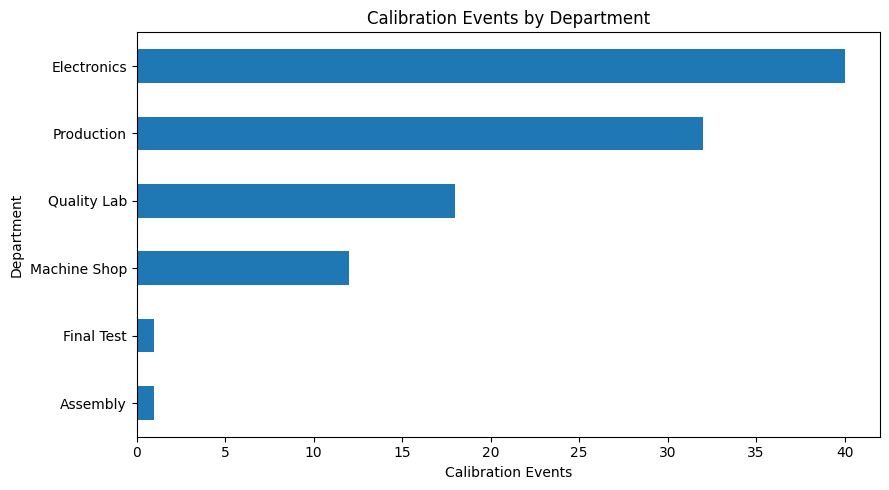

In [5]:
department_counts = (
    traceability["Department"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9, 5))

department_counts.plot(
    kind="barh"
)

plt.title(
    "Calibration Events by Department"
)

plt.xlabel(
    "Calibration Events"
)

plt.ylabel(
    "Department"
)

plt.tight_layout()

plt.savefig(
    IMAGE_FOLDER
    / "department_breakdown.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
setting_counts = (
    traceability["Item Settings"]
    .fillna("Setting Not Recorded")
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(9, 6))

setting_counts.plot(
    kind="barh"
)

plt.title(
    "Most Common Tool Settings"
)

plt.xlabel(
    "Calibration Events"
)

plt.ylabel(
    "Item Setting"
)

plt.tight_layout()

plt.savefig(
    IMAGE_FOLDER
    / "item_setting_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

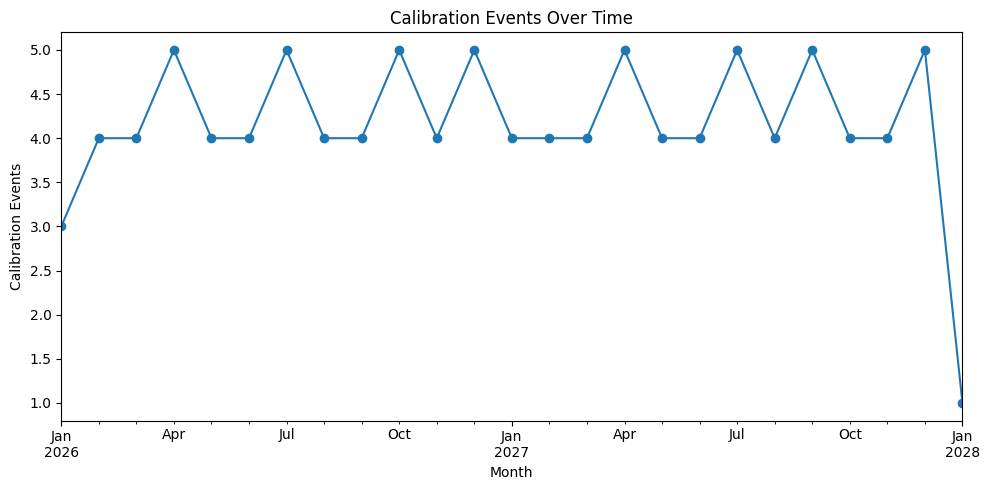

In [6]:
events_by_month = (
    traceability
    .set_index("Calibration Date")
    .resample("MS")
    .size()
)

plt.figure(figsize=(10, 5))

events_by_month.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Calibration Events Over Time"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Calibration Events"
)

plt.tight_layout()

plt.savefig(
    IMAGE_FOLDER
    / "calibration_timeline.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()